<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 11.1</h1>

The aim of this exercise is to introduce the use of neural networks for supervised machine learning, applying them to regression problems. Starting from a simple linear function, we will study how the performance of the network depends on the training parameters and on the properties of the data, and then investigate more complex regression problems.

### Machine Learning

Machine Learning (ML) aims to develop algorithms capable of learning from data and improving their performance without being explicitly programmed for every specific task. Machine learning methods can be broadly divided into three main categories:

- **Supervised learning**, in which the algorithm is trained using labelled data, with the goal of learning a mapping between input and output variables and subsequently predicting the output for new, unseen data.
- **Unsupervised learning**, in which the algorithm is provided with unlabelled data and aims to identify patterns, structures, or relationships within the dataset.
- **Reinforcement learning**, in which the algorithm learns by interacting with an environment and receiving rewards or penalties depending on its actions.

In this exercise, we will focus on **supervised learning**, using a neural network to learn the relationship between the input variable $x$ and the corresponding target value $y$.

### Supervised Learning

A supervised learning problem can be described through three main ingredients:

- The **dataset** $D(X;Y)$, where $X$ represents the independent variables and $Y$ the corresponding dependent variables.
- The **model** $f(X;p)$, which depends on a set of parameters $p$ that are determined during the training process.
- The **cost function** $C(y;f(X;p))$, which measures how well the model reproduces the target values. The optimal model is obtained by finding the parameters $p$ that minimize the cost function.

The dataset is typically divided into a **training set** $D_{\mathrm{train}}$ and a **validation set** $D_{\mathrm{validation}}$, often using a ratio of approximately $90:10$. The model parameters are optimized by minimizing the cost function using only the training data. The performance of the resulting model is then evaluated on the validation set. Since the training parameters have been optimized specifically on $D_{\mathrm{train}}$, the cost evaluated on the validation data is generally larger than that obtained on the training data.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data. We will start by considering the case 

$$
f(x)=2x+1
$$

### Aim of the Exercise

The aim of this part of the exercise is to investigate how the performance of the neural network depends on the main parameters of the training procedure and of the generated dataset. Starting from the linear function

$$
f(x)=2x+1,
$$

we vary the number of training epochs $N_{\mathrm{epochs}}$, the number of training points $N_{\mathrm{train}}$, and the noise level $\sigma$. For each configuration, we analyse the values obtained for the network weight and bias, together with the Mean Squared Error (MSE).

#### Number of epochs

The number of epochs determines how many times the network is exposed to the training dataset. Increasing $N_{\mathrm{epochs}}$ should allow the network to optimize its parameters more effectively, leading the weight and bias towards the expected values $m=2$ and $b=1$. However, using too many epochs can lead to overfitting, especially when the training data contain noise.

#### Number of training points

Increasing $N_{\mathrm{train}}$ provides the network with more information about the underlying function and reduces the influence of statistical fluctuations in the training sample. We therefore expect a more accurate estimate of the weight and bias and, in general, a more stable MSE on the validation set.

#### Noise level

The parameter $\sigma$ controls the magnitude of the noise affecting the generated data. Increasing the noise makes the underlying linear relationship more difficult to identify, so we expect larger fluctuations in the estimated weight and bias and a larger MSE. Conversely, reducing $\sigma$ should allow the network to reproduce the function $f(x)=2x+1$ more accurately.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import csv

I0000 00:00:1789155298.038473 1690656 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789155303.962058 1690656 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789155315.152872 1690656 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
#Reproducibility
np.random.seed(0)
tf.random.set_seed(0)

In [3]:
#Parameters of the true function
m = 2
b = 1

#Parameters of the dataset
N_train = 500
N_valid = 50
sigma = 0.2

#Parameters og the neural network
N_epochs_default = 30
batch_size = 32

In [4]:
#Create de file to save all the neural network's parameter
results_file = "results_11_1.csv"

if not os.path.exists(results_file):
    with open(results_file, "w", newline="") as file:
        writer = csv.writer(file)

        writer.writerow([
            "experiment",
            "N_train",
            "N_valid",
            "sigma",
            "N_epochs",
            "weight",
            "bias",
            "MSE_train",
            "MSE_valid",
            "MSE_true"
        ])

In [5]:
def generate_data(N_train, N_valid, sigma):
    
    #Generate the datasets

    x_train = np.random.uniform(-1, 1, N_train)
    x_valid = np.random.uniform(-1, 1, N_valid)
    x_valid.sort()

    #True function
    y_target = m * x_valid + b

    #Noisy data
    y_train = np.random.normal(m * x_train + b, sigma)
    y_valid = np.random.normal(m * x_valid + b, sigma)

    return(x_train, y_train, x_valid, y_valid, y_target)

In [7]:
def build_model():

    #Build the neural network

    model = Sequential()

    model.add(Input(shape=(1,)))
    model.add(Dense(1))

    #Compile the model

    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    return model

In [8]:
def run_experiment(model, x_train, y_train, x_valid, y_valid, y_target, N_epochs, batch_size):

    #Train the model

    history = model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=N_epochs, shuffle=True, validation_data=(x_valid, y_valid), verbose=0)
    
    #Calculate predictions

    y_pred_train = model(x_train, training=False).numpy().flatten()
    y_pred_valid = model(x_valid, training=False).numpy().flatten()

    #Calculate MSE

    mse_train = np.mean((y_pred_train - y_train)**2)
    mse_valid = np.mean((y_pred_valid - y_valid)**2)
    mse_true = np.mean((y_pred_valid - y_target)**2)

    #Return results

    results = {"MSE_train": mse_train, "MSE_valid": mse_valid, "MSE_true": mse_true}

    return model, history, results

In [9]:
def save_results(N_train, N_valid, sigma, N_epochs, results, model):

    #Learned parameters

    weights, biases = model.get_weights()

    weight = weights[0][0]
    bias = biases[0]

    #Determine experiment number

    if os.path.exists(results_file):

        with open(results_file, "r") as file:
            experiment = sum(1 for _ in file)

    else:
        experiment = 1


    with open(results_file, "a", newline="") as file:

        writer = csv.writer(file)

        writer.writerow([
            experiment,
            N_train,
            N_valid,
            sigma,
            N_epochs,
            weight,
            bias,
            results["MSE_train"],
            results["MSE_valid"],
            results["MSE_true"]
        ])
    

In [10]:
x_train, y_train, x_valid, y_valid, y_target = generate_data(N_train, N_valid, sigma)

In [11]:
#Run experiment for different values of N_epoch

epochs_values = [1, 5, 10, 30, 100]

for N_epochs in epochs_values:

    model = build_model()

    model, history, results = run_experiment(model, x_train, y_train, x_valid, y_valid, y_target, N_epochs, batch_size)

    save_results(N_train, N_valid, sigma, N_epochs, results, model)

E0000 00:00:1789155322.963780 1690656 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
#Run experiment for different values of N_train

N_train_values = [10, 50, 100, 250, 500, 1000]

N_train_max = max(N_train_values)

x_train_max, y_train_max, x_valid, y_valid, y_target = generate_data(N_train_max, N_valid, sigma)

for N_trains in N_train_values:

    x_train = x_train_max[:N_trains]
    y_train = y_train_max[:N_trains]

    model = build_model()

    model, history, results = run_experiment(model, x_train, y_train, x_valid, y_valid, y_target, N_epochs_default, batch_size)

    save_results(N_trains, N_valid, sigma, N_epochs_default, results, model)


In [13]:
#Run experiment for different values of sigma

sigma_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]

for sigma in sigma_values:

    x_train, y_train, x_valid, y_valid, y_target = generate_data(N_train, N_valid, sigma)

    model = build_model()

    model, history, results = run_experiment(model, x_train, y_train, x_valid, y_valid, y_target, N_epochs_default, batch_size)

    save_results(N_train, N_valid, sigma, N_epochs_default, results, model)



In [30]:
#Reading data
data = pd.read_csv("results_11_1.csv")

In [31]:
def plot_weight(data, x_column, xlabel):

    plt.figure(figsize=(8, 5))

    plt.plot(data[x_column], data["weight"], "o-", label="NN weight")

    plt.axhline(2, linestyle="--", label="True value")

    plt.xlabel(xlabel)
    plt.ylabel("$w$")
    plt.title("Learned weight vs " + xlabel)

    plt.grid(True)
    plt.legend()

    plt.show()

In [32]:
def plot_bias(data, x_column, xlabel):

    plt.figure(figsize=(8, 5))

    plt.plot(data[x_column], data["bias"], "o-", label="NN bias")

    plt.axhline(1, linestyle="--", label="True value")

    plt.xlabel(xlabel)
    plt.ylabel("$b$")
    plt.title("Learned bias vs " + xlabel)

    plt.grid(True)
    plt.legend()

    plt.show()

In [33]:
def plot_mse(data, x_column, xlabel, log_x=False, log_y=False):

    plt.figure(figsize=(8, 5))

    plt.plot(data[x_column], data["MSE_train"], "o-", label="Training MSE")

    plt.plot(data[x_column], data["MSE_valid"], "o-", label="Validation MSE")

    plt.plot(data[x_column], data["MSE_true"], "o-", label="True function MSE")

    plt.xlabel(xlabel)
    plt.ylabel("MSE")
    plt.title("MSE vs " + xlabel)

    if log_x:
        plt.xscale("log")

    if log_y:
        plt.yscale("log")

    plt.grid(True)
    plt.legend()

    plt.show()

In [34]:
#Filter for different epochs
epochs_data = data[(data["experiment"] >= 1) & (data["experiment"] <= 5)].sort_values("N_epochs")

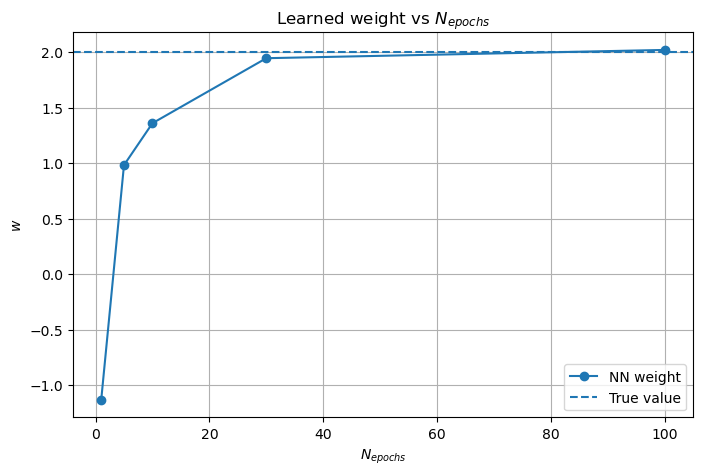

In [35]:
plot_weight(epochs_data, "N_epochs", "$N_{epochs}$")

**Figure 1.** Weight obtained by the neural network as a function of the number of training epochs. As the number of epochs increases, the estimated weight progressively approaches the true value $m=2$, represented by the dashed line, indicating that the network is progressively improving the fit of the underlying linear function.

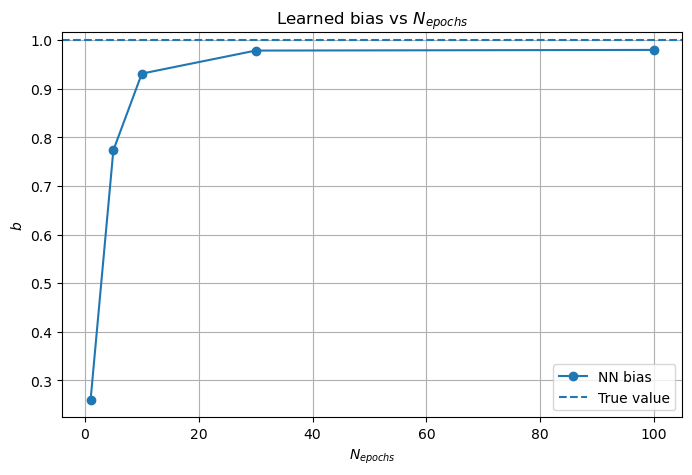

In [36]:
plot_bias(epochs_data, "N_epochs", "$N_{epochs}$")

**Figure 2.** Bias obtained by the neural network as a function of the number of training epochs. Similarly to the weight, the estimated bias approaches the true value $b=1$, represented by the dashed line, as the number of training epochs increases, showing the progressive improvement of the regression.

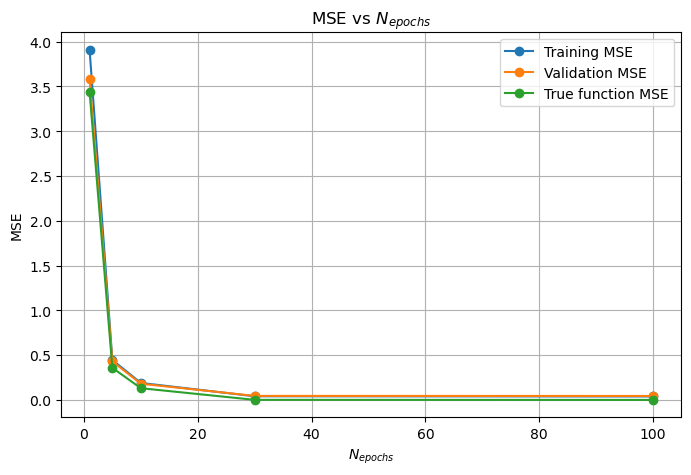

In [37]:
plot_mse(epochs_data, "N_epochs", "$N_{epochs}$")

**Figure 3.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function as a function of the number of training epochs. All three quantities tend to decrease as the number of epochs increases, indicating an improvement in the regression. The training MSE remains slightly lower than the validation MSE, as expected since the network parameters are optimized using the training data. The validation MSE and the training MSE remain comparable, while the MSE with respect to the true function is significantly smaller, reaching a value of approximately $5.74\times10^{-4}$ at the end of the training. The final values of the three MSEs are $0.0391$, $0.0444$, and $0.000574$ for the training, validation, and true-function MSE, respectively.

In [38]:
train_data = data[(data["experiment"] >= 6) & (data["experiment"] <= 11)].sort_values("N_train")

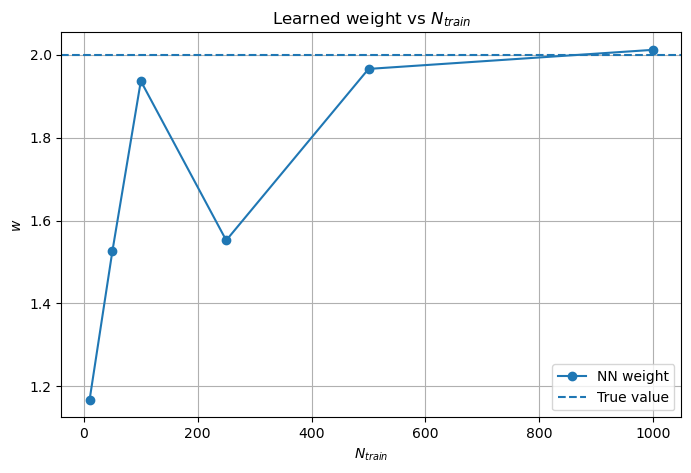

In [39]:
plot_weight(train_data, "N_train", "$N_{train}$")

**Figure 4.** Weight obtained by the neural network as a function of the number of training data points. As $N_{\mathrm{train}}$ increases, the estimated weight approaches the true value $m=2$, represented by the dashed line. The larger training dataset provides more information about the underlying linear relation and reduces the influence of statistical fluctuations in the sampled data.

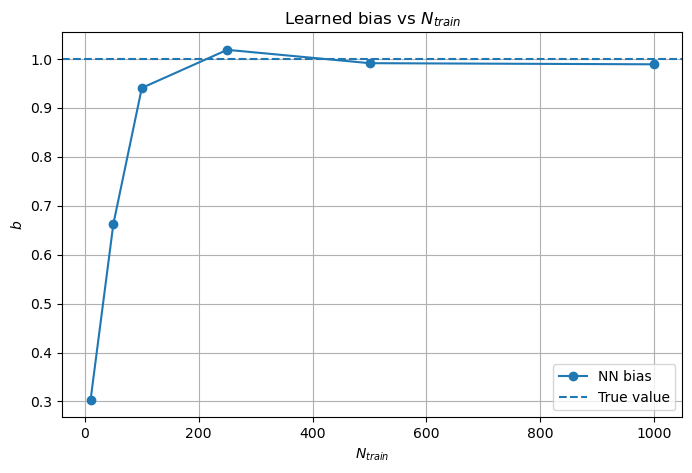

In [40]:
plot_bias(train_data, "N_train", "$N_{train}$")

**Figure 5.** Bias obtained by the neural network as a function of the number of training data points. The estimated bias approaches the true value $b=1$, represented by the dashed line, as the number of training points increases. This indicates that a larger training dataset allows the network to determine the parameters of the underlying linear function more accurately.

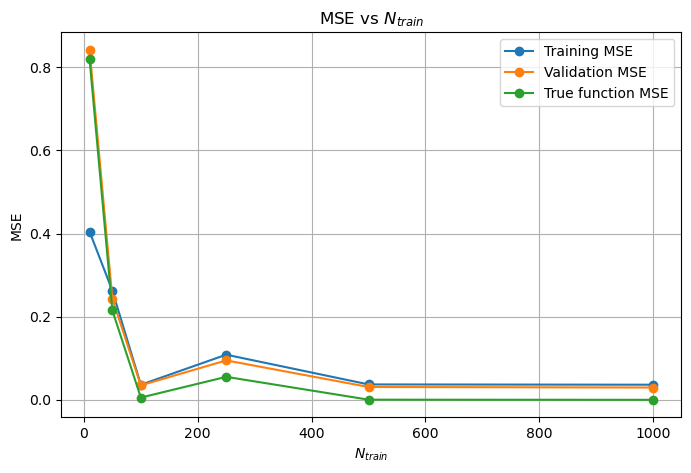

In [41]:
plot_mse(train_data, "N_train", "$N_{train}$")

**Figure 6.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function as a function of the number of training data points. The MSEs remain of comparable magnitude for the training and validation sets, while the MSE with respect to the true function is significantly smaller. The final values are $0.0365$, $0.0297$, and $1.26\times10^{-4}$ for the training, validation, and true-function MSE, respectively. The results show that increasing the number of training points allows the network to obtain a more accurate representation of the underlying function.

In [42]:
sigma_data = data[(data["experiment"] >= 12) & (data["experiment"] <= 17)].sort_values("sigma")

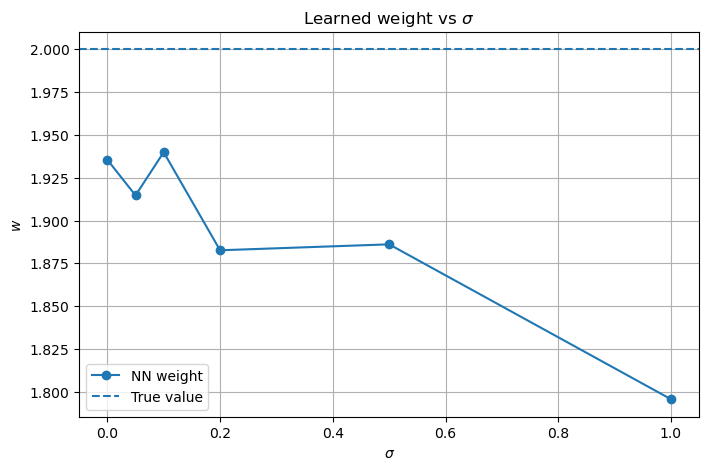

In [43]:
plot_weight(sigma_data, "sigma", "$\sigma$")

**Figure 7.** Weight obtained by the neural network as a function of the noise level $\sigma$. As the noise increases, the estimated weight progressively deviates from the true value $m=2$, represented by the dashed line. The larger fluctuations introduced in the training data make it more difficult for the network to identify the underlying linear relationship accurately.

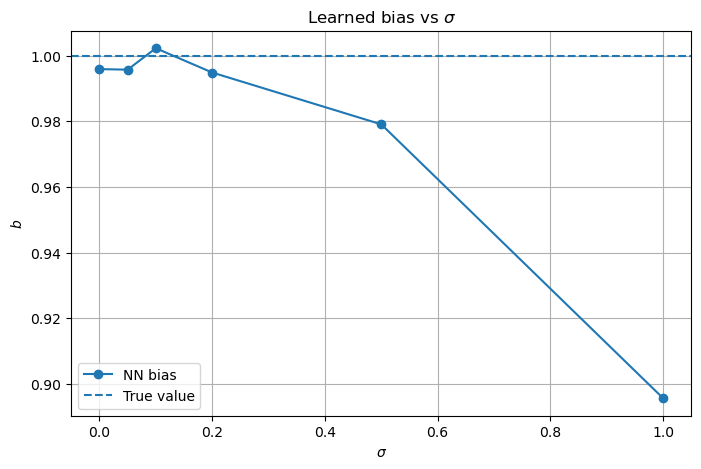

In [44]:
plot_bias(sigma_data, "sigma", "$\sigma$")

**Figure 8.** Bias obtained by the neural network as a function of the noise level $\sigma$. Increasing the noise level causes the estimated bias to progressively deviate from the true value $b=1$, represented by the dashed line. This reflects the increasing difficulty of determining the parameters of the underlying function in the presence of stronger statistical fluctuations.

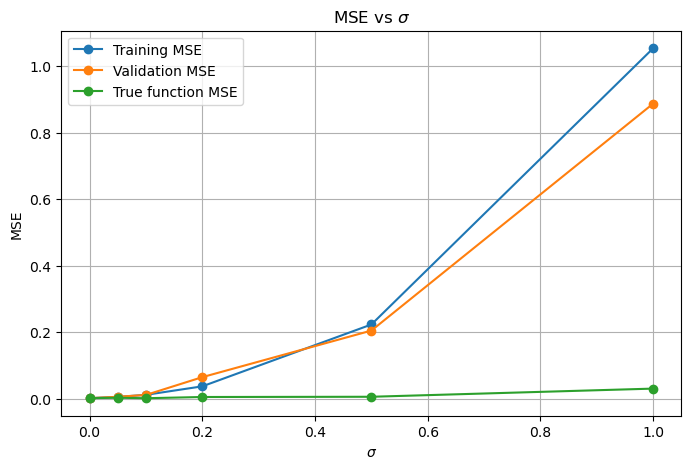

In [45]:
plot_mse(sigma_data, "sigma", "$\sigma$")

**Figure 9.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function as a function of the noise level $\sigma$. The three MSEs generally increase as the noise level becomes larger, indicating that stronger fluctuations in the data make the underlying linear relation more difficult to reproduce. The final values are $1.0542$, $0.8877$, and $0.0300$ for the training, validation, and true-function MSE, respectively. The results show that increasing the noise significantly reduces the accuracy with which the network can determine the parameters of the underlying function.